In [ ]:
#this notebook is to be used for testing redback only in the hopes to get the correct version and therefore get model using gavins code working !! 

In [1]:
import redback
from redback.model_library import all_models_dict

# Search for any key containing '1998'
matches = [key for key in all_models_dict.keys() if '1998' in key]
print(f"Matching models: {matches}")

No module named 'lalsimulation'
lalsimulation is not installed. Some EOS based models will not work. Please use bilby eos or pass your own EOS generation class to the model
13:14 bilby INFO    : Running bilby version: 2.3.0
13:14 redback INFO    : Running redback version: 1.12.1


Matching models: []


In [2]:
from redback.transient_models.supernova_models import sn1998bw_template

# Test it works
print(sn1998bw_template)

ImportError: cannot import name 'sn1998bw_template' from 'redback.transient_models.supernova_models' (/opt/miniconda3/envs/redback/lib/python3.12/site-packages/redback/transient_models/supernova_models.py)

In [3]:
try:
    from redback.transient_models.template_models import sn1998bw_template
    print("Found in template_models!")
except ImportError:
    print("Not in template_models.")

Not in template_models.


In [4]:
from redback.model_library import all_models_dict
print(all_models_dict.get('sn1998bw', "Still not found"))

Still not found


In [6]:
import redback
import pkgutil
import importlib

# This will search all modules inside redback for any attribute containing '1998bw'
print("Searching for 1998bw references...")
found = False
for importer, modname, ispkg in pkgutil.walk_packages(redback.__path__, redback.__name__ + "."):
    try:
        # Dynamically import the module
        module = importlib.import_module(modname)
        for attr in dir(module):
            if "1998bw" in attr.lower():
                print(f"Found match: '{attr}' in module '{modname}'")
                found = True
    except Exception:
        continue

if not found:
    print("No direct function found. Checking available keys in all_models_dict...")
    from redback.model_library import all_models_dict
    keys = [k for k in all_models_dict.keys() if "sn" in k.lower()]
    print(f"Sample of available SN keys: {keys[:10]}")

Searching for 1998bw references...
No direct function found. Checking available keys in all_models_dict...
Sample of available SN keys: ['bazin_sne', 'villar_sne', 'general_magnetar_slsn', 'general_magnetar_slsn_bolometric', 'slsn', 'slsn_bolometric', 'sn_exponential_powerlaw', 'sn_fallback', 'sn_nickel_fallback', 'sncosmo_models']


In [7]:
# This bypasses the dictionary and goes straight to the source file
from redback.transient_models.supernova_models import sn1998bw_template

# Verify it's a function
print(type(sn1998bw_template))

ImportError: cannot import name 'sn1998bw_template' from 'redback.transient_models.supernova_models' (/opt/miniconda3/envs/redback/lib/python3.12/site-packages/redback/transient_models/supernova_models.py)

In [8]:
import sys
# This forces python to look at the raw file
import redback.transient_models.supernova_models as sn_raw
if hasattr(sn_raw, 'sn1998bw_template'):
    sn1998bw_template = sn_raw.sn1998bw_template
    print("Success!")
else:
    print("Function truly does not exist in your installed version.")

Function truly does not exist in your installed version.


In [9]:

def sn1998bw_template(time, redshift, amplitude, **kwargs):
    """
    A wrapper to the SN1998bw template. Only valid between 1100-11000 Angstrom and 0.01 to 90 days post explosion in rest frame

    Parameters
    ----------
    time
        time in days in observer frame (post explosion)
    redshift
        redshift
    amplitude
        amplitude scaling factor, where 1.0 is the original brightness of SN1998bw; and f_lambda is scaled by this factor
    kwargs
        Additional keyword arguments required by redback.
    frequency
        Required if output_format is 'flux_density'. frequency to calculate - Must be same length as time array or a single number).
    bands
        Required if output_format is 'magnitude' or 'flux'.
    output_format
        'flux_density', 'magnitude', 'spectra', 'flux', 'sncosmo_source'
    cosmology
        Cosmology to use for luminosity distance calculation. Defaults to Planck18. Must be a astropy.cosmology object.
    Returns
    -------
        set by output format - 'flux_density', 'magnitude', 'spectra', 'flux', 'sncosmo_source'

    """
    import sncosmo
    model = sncosmo.Model(source='v19-1998bw')
    original_redshift = 0.0085
    cosmology = kwargs.get("cosmology", cosmo)
    original_dl = (43*uu.Mpc).to(uu.cm).value

    # From roughly matching to Galama+ or Clocchiatti+1998bw light curves
    original_peak_time = 15
    model.set(z=original_redshift, t0=original_peak_time)
    model.set_source_peakmag(14.25, band='bessellb', magsys='ab')
    tts = np.geomspace(0.01, 90, 200)
    lls = np.linspace(1620, 11000, 300)
    f_lambda = model.flux(tts, lls) #erg/s/cm^2/Angstrom.
    l_lambda = f_lambda * 4 * np.pi * original_dl**2  # erg/s/Angstrom

    # We consider this the rest frame spectrum of 1998bw. Now we can redshift it and scale it.
    time_obs = tts * (1 + redshift)
    lambda_obs = lls * (1 + redshift)
    dl_new = cosmology.luminosity_distance(redshift).cgs.value
    f_lambda_obs = l_lambda / (4 * np.pi * dl_new**2)
    f_lambda_obs = amplitude * f_lambda_obs * (1 + redshift) # accounting for bandwidth stretching
    f_lambda_obs = f_lambda_obs * uu.erg / uu.s / uu.cm ** 2 / uu.Angstrom
    if kwargs['output_format'] == 'flux_density':
        frequency = kwargs['frequency']
        # work in obs frame
        ff_array = lambda_to_nu(lambda_obs)

        # Convert flux density to mJy
        fmjy = f_lambda_obs.to(uu.mJy, equivalencies=uu.spectral_density(wav=lambda_obs * uu.Angstrom)).value
        # Create interpolator on obs frame grid
        flux_interpolator = RegularGridInterpolator(
            (time_obs, ff_array),
            fmjy,
            bounds_error=False,
            fill_value=0.0)

        # Prepare points for interpolation
        if isinstance(frequency, (int, float)):
            frequency = np.ones_like(time) * frequency

        # Create points for evaluation
        points = np.column_stack((time, frequency))

        # Return interpolated flux density with (1+z) correction for observer frame
        return flux_interpolator(points)
    elif kwargs['output_format'] == 'spectra':
        return namedtuple('output', ['time', 'lambdas', 'spectra'])(time=time_obs,
                                                                    lambdas=lambda_obs,
                                                                    spectra=f_lambda_obs)
    else:
        return sed.get_correct_output_format_from_spectra(time=time, time_eval=time_obs,
                                                          spectra=f_lambda_obs, lambda_array=lambda_obs,
                                                          **kwargs)

# After pasting the function definition into your cell:
from redback.model_library import all_models_dict

all_models_dict['sn1998bw_template'] = sn1998bw_template

# Now any redback functions that look in the dictionary will find it!


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo 
import astropy.units as uu
from redback.transient_models.supernova_models import lambda_to_nu
import redback.interaction_processes as ip
import redback.sed as sed
import redback.photosphere as photosphere

import astropy.units as uu

import extinction
from extinction import ccm89, fitzpatrick99, apply, remove
from scipy.interpolate import RegularGridInterpolator
import sncosmo

func = all_models_dict['sn1998bw_template']

time = np.array((11))
red = 0.085
freq = 3e14 #lower limit = 2.75e14 - if 2.0e14 does this give inf ?? YES - BE VERY CAREFUOL WITH THE FREQUENCY RANGES !! 

sn_1998b2 = func(time=time,redshift=red,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo)
sn_1998b1 = func(time=time,redshift=0.085,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo)

print(sn_1998b2, sn_1998b1, sn_1998b2/sn_1998b1)

[0.0645697] [0.0645697] [1.]


In [ ]:
#THIS WORKS !! ???!!! 
#BETWEEN FREQUENCIES 3E14 - 1E15 THIS RETURNS F_98 VALUE WHICH IS CORRECT !! 

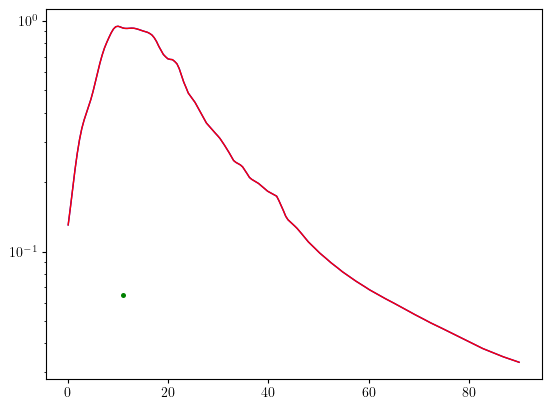

In [34]:
#TESTING TO GET F_98 = 1 !! 

#WHAT FREQUENCY GETS THIS TO B F_98 = 1? 
#use jillians values ? 
freq = 1e15
redshift = 0.0085
times = np.linspace(0.1,90,200)
sn_1998bw = func(time=times,redshift=redshift,amplitude=1.0,output_format='flux_density',frequency=freq)
sn_1998bw1 = func(time=times,redshift=0.0085,amplitude=1.0,frequency=freq,output_format='flux_density')

plt.semilogy(times,sn_1998bw,'-b')
plt.semilogy(times,sn_1998bw1, '-r')
#this point is the arbitrary GRB event at the epoch 
plt.semilogy(time,sn_1998b1, marker='o',color='green')
#plt.ylim(19,13)
plt.show()